In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans, DBSCAN
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.neighbors import NearestNeighbors


## Загрузка данных ##

In [2]:
df = pd.read_csv('teacher_activity_logs.csv')

In [3]:
df.head()

,user_id,timestamp,event_type,module,session_id,region,school_id
0,BOT001,2026-03-01 00:00:48,webinar_hosted,Вебинары,SBOT,Москва,1
1,BOT004,2026-03-01 00:01:44,webinar_started,Вебинары,SBOT,Москва,1
2,BOT014,2026-03-01 00:02:41,material_downloaded,Библиотека материалов,SBOT,Москва,1
3,BOT001,2026-03-01 00:03:38,webinar_hosted,Вебинары,SBOT,Москва,1
4,BOT002,2026-03-01 00:04:31,homework_assigned,Домашние задания,SBOT,Москва,1


In [4]:
df['session_id'].nunique()

3971

In [5]:
df['session_id'].unique()

array(['SBOT', 'S3270', 'S4461', ..., 'S1904', 'S1849', 'S2694'],
      shape=(3971,), dtype=object)

In [6]:
df.duplicated().sum()

np.int64(29)

user_id	- 
timestamp	
event_type	
module	
session_id	
region	
school_id

In [7]:
df[df.duplicated()]

,user_id,timestamp,event_type,module,session_id,region,school_id
7359,BOT000,2026-03-02 14:41:32,schedule_viewed,Расписание,SBOT,Москва,1
21797,T100896,2026-03-05 15:53:00,homework_assigned,Домашние задания,S1896,Екатеринбург,377
24631,T100265,2026-03-06 08:37:00,homework_assigned,Домашние задания,S2265,Краснодар,61
29991,T101109,2026-03-07 10:39:00,homework_assigned,Домашние задания,S4112,Казань,48
30369,BOT003,2026-03-07 11:53:01,grade_entered,Оценки,SBOT,Москва,1
58227,T101392,2026-03-13 10:07:00,grade_viewed,Оценки,S2395,Москва,51
65182,T101195,2026-03-14 18:47:00,homework_checked,Домашние задания,S4198,Новосибирск,26
65550,T100518,2026-03-14 20:08:00,homework_assigned,Домашние задания,S2518,Краснодар,312
67527,T100257,2026-03-15 10:24:00,homework_checked,Домашние задания,S2257,Санкт-Петербург,54
83855,T101298,2026-03-18 16:48:00,webinar_hosted,Вебинары,S2301,Москва,225


In [8]:
df['module'].isnull().sum()

np.int64(12806)

In [9]:
event_per_user = df.groupby('user_id').size()

**Количество событий**

In [10]:
print(event_per_user.sort_values(ascending=False).head())

user_id
BOT014    6687
BOT003    6555
BOT001    6553
BOT009    6492
BOT012    6466
dtype: int64


**Предполагаем что BOT это тестовые аккаунты так как они имеют аномальное количество входов и событий а так же  имеют пропуски в столбце module.**


In [11]:
bot_mask = df['user_id'].str.startswith('BOT')

In [12]:
print("Событий от BOT:", bot_mask.sum())
print("BOT-пользователей:", df.loc[bot_mask, 'user_id'].nunique())

Событий от BOT: 94291
BOT-пользователей: 15


In [13]:
df_1 = df[~bot_mask].copy()

**Восстановим module из event type**

In [14]:
module_map = {
    'homework_assigned': 'Домашние задания',
    'homework_checked': 'Домашние задания',
    'schedule_viewed': 'Расписание',
    'material_viewed': 'Библиотека материалов',
    'material_downloaded': 'Библиотека материалов',
    'grade_viewed': 'Оценки',
    'grade_entered': 'Оценки',
    'webinar_started': 'Вебинары',
    'webinar_hosted': 'Вебинары'}
mask = df_1['module'].isna()

df_1.loc[mask, 'module'] = (df_1.loc[mask, 'event_type'].map(module_map))

In [15]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120668 entries, 621 to 214691
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   user_id     120668 non-null  object
 1   timestamp   120668 non-null  object
 2   event_type  120668 non-null  object
 3   module      120668 non-null  object
 4   session_id  120668 non-null  object
 5   region      120668 non-null  object
 6   school_id   120668 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 7.4+ MB


## Работа с временными рядами ##

In [16]:
df_1['timestamp'] = pd.to_datetime(df_1['timestamp'])

In [17]:
df_1.sort_values(['user_id', 'timestamp'])

,user_id,timestamp,event_type,module,session_id,region,school_id
11604,T100000,2026-03-03 13:05:00,webinar_hosted,Вебинары,S40,Уфа,277
12418,T100000,2026-03-03 16:01:00,schedule_viewed,Расписание,S40,Уфа,277
13024,T100000,2026-03-03 18:14:00,webinar_hosted,Вебинары,S10,Уфа,277
19651,T100000,2026-03-05 08:14:00,webinar_started,Вебинары,S10,Уфа,277
20036,T100000,2026-03-05 09:43:00,webinar_started,Вебинары,S10,Уфа,277
...,...,...,...,...,...,...,...
193952,T101499,2026-04-10 16:27:00,homework_checked,Домашние задания,S3502,Казань,40
194488,T101499,2026-04-10 18:26:00,webinar_hosted,Вебинары,S1502,Казань,40
197045,T101499,2026-04-11 09:56:00,webinar_hosted,Вебинары,S1502,Казань,40
197582,T101499,2026-04-11 11:45:00,schedule_viewed,Расписание,S4502,Казань,40


In [18]:
df_1['time_diff'] = (df_1.groupby('user_id')['timestamp'].diff().dt.total_seconds()/3600)

In [19]:
df_1.head()

,user_id,timestamp,event_type,module,session_id,region,school_id,time_diff
621,T100270,2026-03-01 07:00:00,homework_checked,Домашние задания,S3270,Санкт-Петербург,118,NaN
622,T100461,2026-03-01 07:00:00,homework_checked,Домашние задания,S4461,Пермь,202,NaN
623,T101165,2026-03-01 07:00:00,material_viewed,Библиотека материалов,S1168,Краснодар,185,NaN
624,T100671,2026-03-01 07:00:00,material_viewed,Библиотека материалов,S4671,Москва,178,NaN
625,T100246,2026-03-01 07:00:00,material_downloaded,Библиотека материалов,S4246,Уфа,306,NaN


In [20]:
df_1['time_diff'] = df_1['time_diff'].fillna(0)

In [21]:
df_1['hour'] = df_1['timestamp'].dt.hour
df_1['date'] = df_1['timestamp'].dt.date
df_1['weekday'] = df_1['timestamp'].dt.weekday
df_1['weekend'] = (df_1['weekday'] >= 5).astype(int)

In [22]:
df_1['late_reg'] = (df_1['hour'] >= 18).astype(int)

In [23]:
df_1[df_1['late_reg'] ==1]

,user_id,timestamp,event_type,module,session_id,region,school_id,time_diff,hour,date,weekday,weekend,late_reg
3555,T101313,2026-03-01 18:00:00,grade_entered,Оценки,S2316,Москва,387,3.366667,18,2026-03-01,6,1,1
3556,T100242,2026-03-01 18:00:00,homework_checked,Домашние задания,S2242,Пермь,171,1.333333,18,2026-03-01,6,1,1
3557,T100506,2026-03-01 18:00:00,material_viewed,Библиотека материалов,S1506,Уфа,199,3.666667,18,2026-03-01,6,1,1
3558,T100595,2026-03-01 18:00:00,homework_assigned,Домашние задания,S4595,Казань,69,2.666667,18,2026-03-01,6,1,1
3559,T101405,2026-03-01 18:00:00,schedule_viewed,Расписание,S3408,Пермь,60,1.416667,18,2026-03-01,6,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
214686,T100024,2026-04-14 20:58:00,material_viewed,Библиотека материалов,S424,Казань,320,5.966667,20,2026-04-14,1,0,1
214688,T100780,2026-04-14 20:59:00,homework_assigned,Домашние задания,S1780,Москва,285,0.366667,20,2026-04-14,1,0,1
214689,T100681,2026-04-14 20:59:00,homework_checked,Домашние задания,S1681,Москва,307,3.633333,20,2026-04-14,1,0,1
214690,T100518,2026-04-14 20:59:00,homework_assigned,Домашние задания,S4518,Краснодар,312,5.333333,20,2026-04-14,1,0,1


## Агрегация ##

In [24]:
features_1 = df_1.groupby('user_id').agg(
    event = ('event_type', 'count'),
    active_days = ('date', 'nunique'),
    sessions = ('session_id', 'nunique'),

    mean_hour = ('hour', 'mean'),
    median_hour = ('hour', 'median'),
    
    weekend_share=('weekend', 'mean'),
    late_share=('late_reg', 'mean'),

    mean_time_diff=('time_diff', 'mean'),
    median_time_diff=('time_diff', 'median'))
    

In [25]:
module_cross = pd.crosstab(df_1['user_id'],df_1['module'])

In [26]:
module_cross

module,Библиотека материалов,Вебинары,Домашние задания,Оценки,Расписание
user_id,,,,,
T100000,3,20,3,3,9
T100001,27,2,5,2,4
T100002,5,2,2,2,5
T100003,2,22,2,3,4
T100004,13,11,93,33,5
...,...,...,...,...,...
T101495,32,3,4,4,11
T101496,0,1,3,4,3
T101497,30,3,2,3,2


In [27]:
df_1.groupby('user_id')['region'].nunique().value_counts()

region
1    1500
Name: count, dtype: int64

In [28]:
events_cross = pd.crosstab(df_1['user_id'], df_1['event_type'])

In [29]:
events_cross

event_type,grade_entered,grade_viewed,homework_assigned,homework_checked,material_downloaded,material_viewed,schedule_viewed,webinar_hosted,webinar_started
user_id,,,,,,,,,
T100000,0,3,3,0,2,1,9,11,9
T100001,1,1,2,3,12,15,4,1,1
T100002,1,1,1,1,3,2,5,2,0
T100003,1,2,1,1,2,0,4,13,9
T100004,14,19,43,50,5,8,5,10,1
...,...,...,...,...,...,...,...,...,...
T101495,3,1,4,0,16,16,11,1,2
T101496,3,1,0,3,0,0,3,1,0
T101497,1,2,1,1,17,13,2,2,1


In [30]:
region = pd.get_dummies(
    df_1[['user_id', 'region']].drop_duplicates('user_id'),
    columns=['region'],
    dtype=int
).set_index('user_id')

In [31]:
final_df = features_1.join(module_cross)
final_df = final_df.join(events_cross)
final_df = final_df.join(region)

In [32]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, T100000 to T101499
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event                   1500 non-null   int64  
 1   active_days             1500 non-null   int64  
 2   sessions                1500 non-null   int64  
 3   mean_hour               1500 non-null   float64
 4   median_hour             1500 non-null   float64
 5   weekend_share           1500 non-null   float64
 6   late_share              1500 non-null   float64
 7   mean_time_diff          1500 non-null   float64
 8   median_time_diff        1500 non-null   float64
 9   Библиотека материалов   1500 non-null   int64  
 10  Вебинары                1500 non-null   int64  
 11  Домашние задания        1500 non-null   int64  
 12  Оценки                  1500 non-null   int64  
 13  Расписание              1500 non-null   int64  
 14  grade_entered           1500 non-nul

In [33]:
final_df.head()

,event,active_days,sessions,mean_hour,median_hour,weekend_share,late_share,mean_time_diff,median_time_diff,Библиотека материалов,...,webinar_hosted,webinar_started,region_Екатеринбург,region_Казань,region_Краснодар,region_Москва,region_Новосибирск,region_Пермь,region_Санкт-Петербург,region_Уфа
user_id,,,,,,,,,,,,,,,,,,,,,
T100000,38,11,4,12.578947,11.0,0.105263,0.210526,22.904386,3.050000,3,...,11,9,0,0,0,0,0,0,0,1
T100001,40,18,4,13.375000,13.0,0.250000,0.225000,21.852917,6.616667,27,...,1,1,0,0,1,0,0,0,0,0
T100002,16,8,4,14.125000,14.5,0.250000,0.312500,66.264583,11.091667,5,...,2,0,0,0,0,0,0,1,0,0
T100003,33,9,4,14.272727,14.0,0.393939,0.272727,21.095455,3.283333,2,...,13,9,0,0,0,0,0,1,0,0
T100004,155,31,4,13.290323,13.0,0.412903,0.219355,6.875376,1.900000,13,...,10,1,0,0,1,0,0,0,0,0


# Масштабирование #

In [34]:
col_scale = ['event', 'active_days', 'sessions', 'mean_hour', 'median_hour',
       'weekend_share', 'late_share', 'mean_time_diff', 'median_time_diff',
       'Библиотека материалов', 'Вебинары', 'Домашние задания', 'Оценки',
       'Расписание', 'grade_entered', 'grade_viewed', 'homework_assigned',
       'homework_checked', 'material_downloaded', 'material_viewed',
       'schedule_viewed', 'webinar_hosted', 'webinar_started']

In [35]:
scaler = StandardScaler()

In [36]:
scal = scaler.fit_transform(final_df[col_scale])
fin_scal = pd.DataFrame(scal, columns = col_scale, index = final_df.index)

skal_df = final_df.copy()
skal_df[col_scale] = fin_scal

# Modeling #

# K-means #

## Cилуэт ##

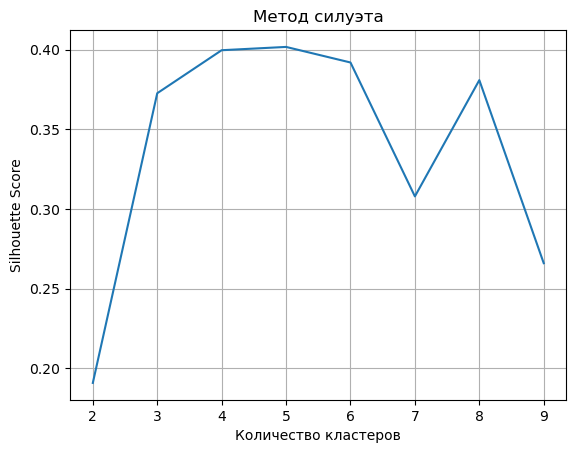

In [37]:
n_cluster = list(range(2,10))
metrics = []
for k in n_cluster:
    km = KMeans(n_clusters = k,random_state = 42)
    km.fit(skal_df)
    score = silhouette_score(skal_df, km.labels_)
    metrics.append(score)
sns.lineplot(x=n_cluster, y=metrics)
plt.title('Метод силуэта')
plt.xlabel('Количество кластеров')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()
                 

## Локоть ##

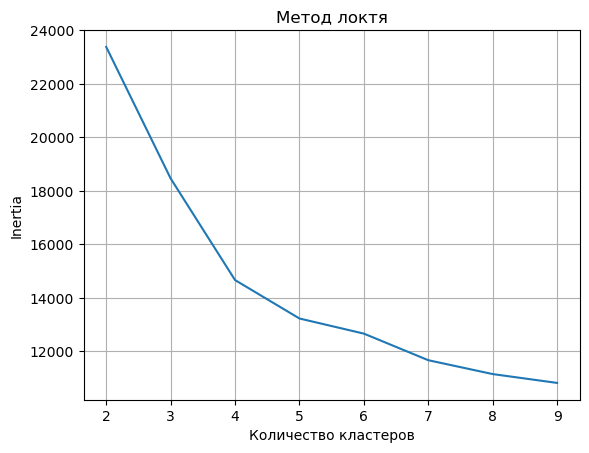

In [38]:
n_cluster = list(range(2,10))
metrics = []
for i in n_cluster:
    km = KMeans(n_clusters = i)
    km.fit(skal_df)
    metrics.append(km.inertia_)
sns.lineplot(x = n_cluster, y = metrics)
plt.title('Метод локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

**Методы оценки сошлись на 4**

In [39]:
km = KMeans(n_clusters = 4,random_state = 42)
km.fit(skal_df)
df_plot = skal_df.copy()
df_plot['cluster'] = km.predict(skal_df).round(0)

In [40]:
df_plot['cluster'].value_counts().sort_values()

cluster
1    210
2    326
0    449
3    515
Name: count, dtype: int64

In [41]:
col_time = ['mean_hour', 'median_hour',
        'mean_time_diff', 'median_time_diff', 'sessions']

col_module = ['Библиотека материалов', 'Вебинары', 'Домашние задания', 'Оценки',
       'Расписание']

col_event = ['grade_entered', 'grade_viewed', 'homework_assigned',
       'homework_checked', 'material_downloaded', 'material_viewed',
       'schedule_viewed', 'webinar_hosted', 'webinar_started']

In [42]:
fraction_col = ['weekend_share', 'late_share']

In [43]:
final_df['cluster'] = df_plot['cluster']

In [44]:
df_time = final_df.groupby('cluster')[col_time].mean()
df_module = final_df.groupby('cluster')[col_module].mean()
df_event = final_df.groupby('cluster')[col_event].mean()
active_days = final_df.groupby('cluster')['active_days'].mean()

In [45]:
active_days

cluster
0    33.679287
1    11.623810
2     6.831288
3    17.990291
Name: active_days, dtype: float64

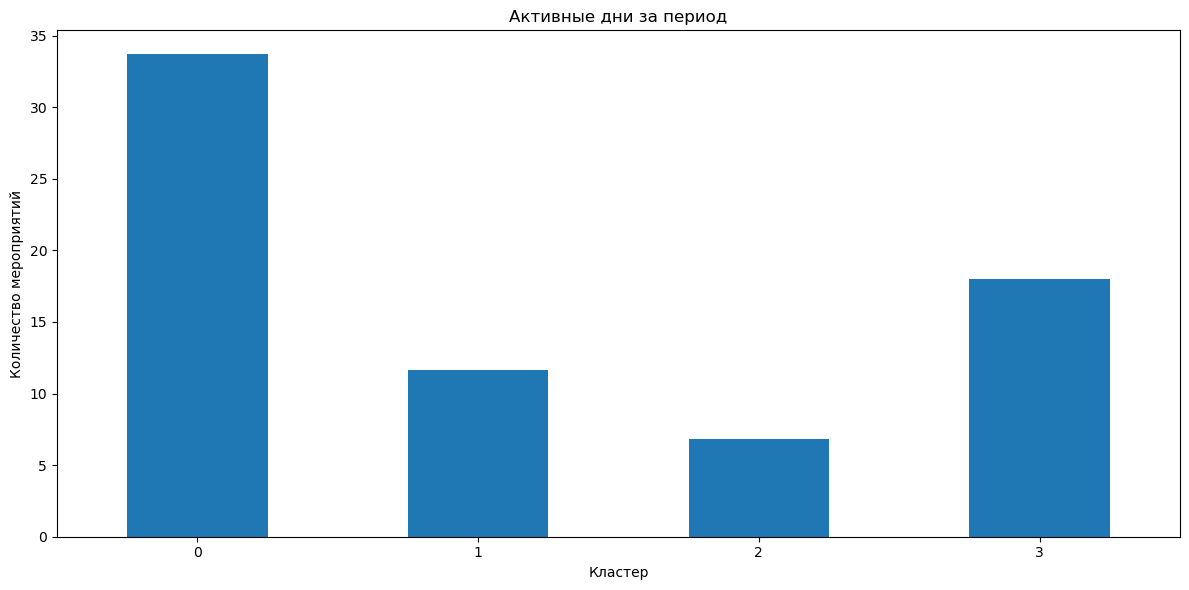

In [46]:
active_days.plot(
    kind='bar',
    figsize=(12, 6))

plt.title('Активные дни за период')
plt.xlabel('Кластер')
plt.ylabel('Количество мероприятий')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [47]:
df_time.head()

,mean_hour,median_hour,mean_time_diff,median_time_diff,sessions
cluster,,,,,
0,13.507163,13.530067,5.729806,2.030011,4.000000
1,13.537088,13.507143,20.614640,2.803254,4.000000
2,13.592384,13.538344,64.040301,13.262756,3.825153
3,13.466925,13.434951,22.597052,5.748770,4.000000


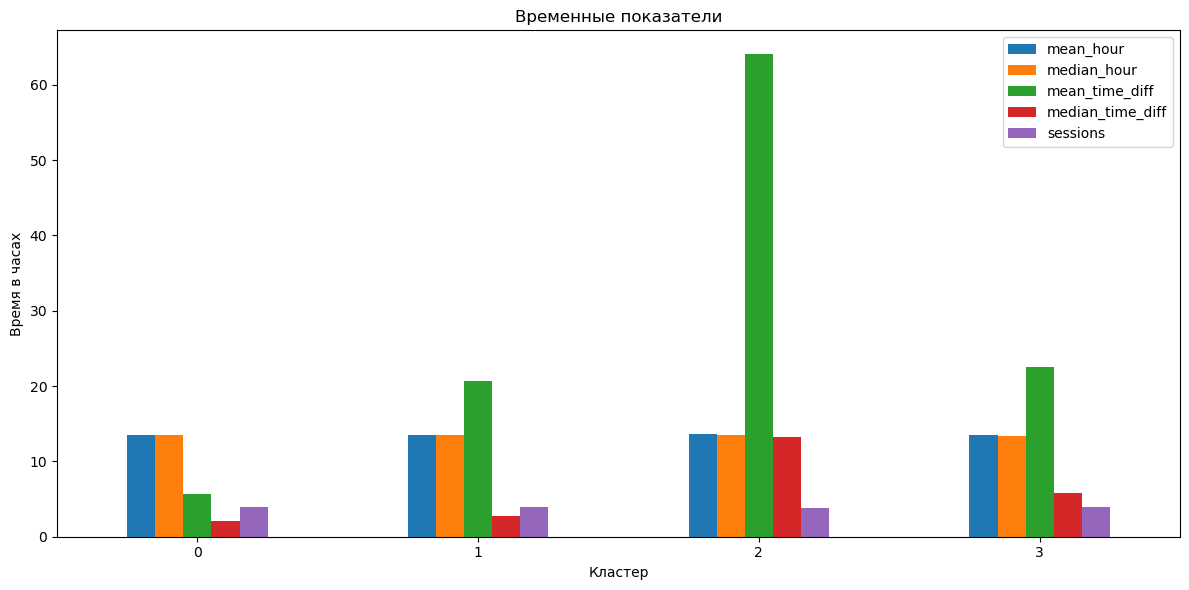

In [48]:
df_time.plot(
    kind='bar',
    figsize=(12, 6))

plt.title('Временные показатели')
plt.xlabel('Кластер')
plt.ylabel('Время в часах')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [49]:
df_module

,Библиотека материалов,Вебинары,Домашние задания,Оценки,Расписание
cluster,,,,,
0,18.688196,9.371938,101.703786,45.792873,9.465479
1,4.500000,25.680952,4.714286,4.685714,7.290476
2,4.352761,1.628834,2.641104,2.466258,2.861963
3,29.200000,2.207767,4.718447,2.238835,6.687379


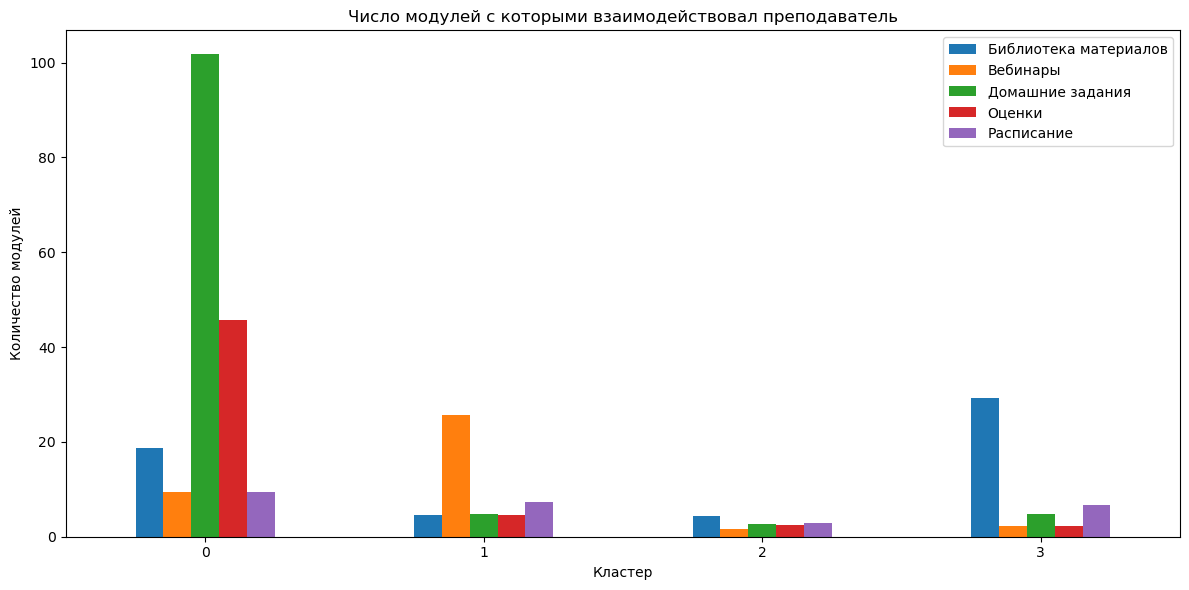

In [50]:
df_module.plot(
    kind='bar',
    figsize=(12, 6))

plt.title('Число модулей с которыми взаимодействовал преподаватель')
plt.xlabel('Кластер')
plt.ylabel('Количество модулей')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [51]:
df_event

,grade_entered,grade_viewed,homework_assigned,homework_checked,material_downloaded,material_viewed,schedule_viewed,webinar_hosted,webinar_started
cluster,,,,,,,,,
0,22.730512,23.062361,50.832962,50.870824,9.300668,9.387528,9.465479,4.530067,4.841871
1,2.380952,2.304762,2.376190,2.338095,2.323810,2.176190,7.290476,12.847619,12.833333
2,1.159509,1.306748,1.300613,1.340491,2.184049,2.168712,2.861963,0.828221,0.800613
3,1.120388,1.118447,2.425243,2.293204,14.607767,14.592233,6.687379,1.120388,1.087379


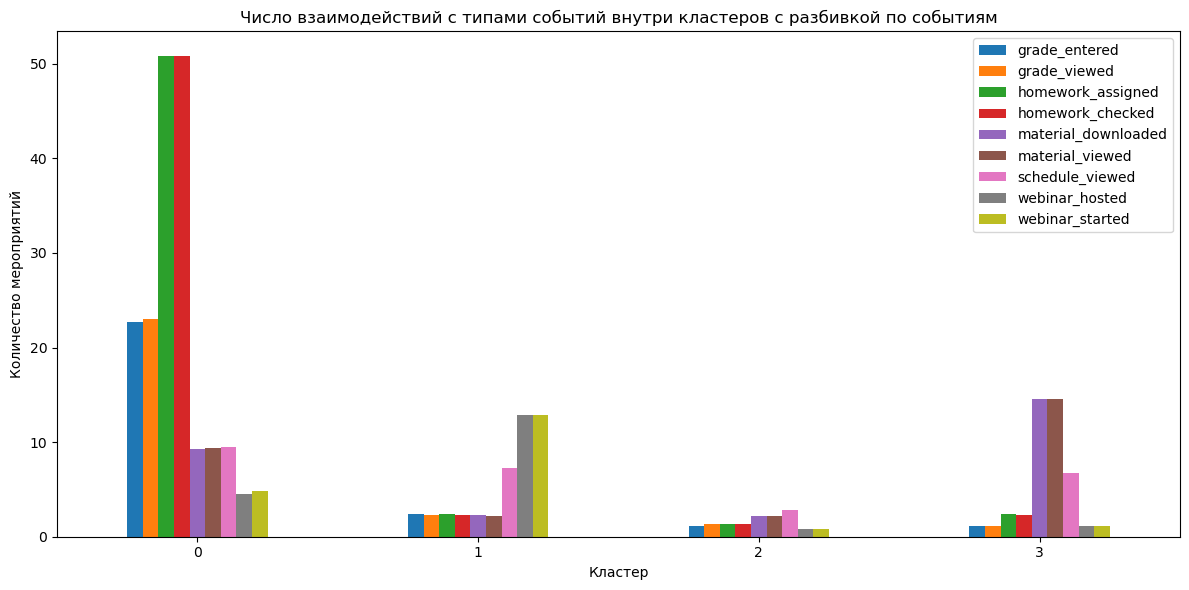

In [52]:
df_event.plot(
    kind='bar',
    figsize=(12, 6))

plt.title('Число взаимодействий с типами событий внутри кластеров с разбивкой по событиям')
plt.xlabel('Кластер')
plt.ylabel('Количество мероприятий')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

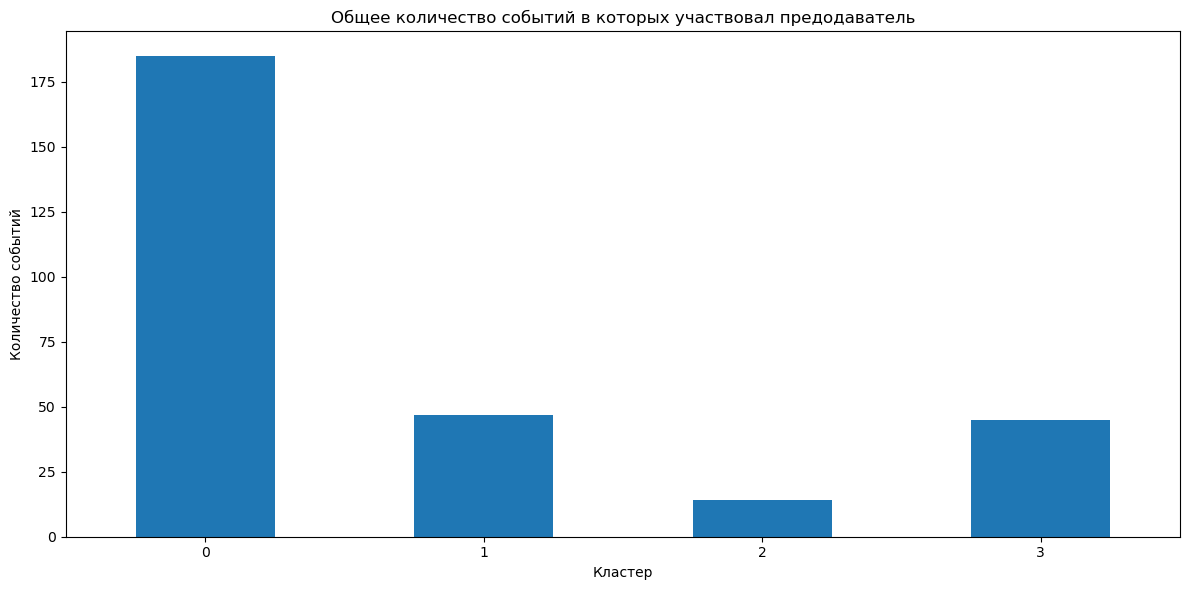

In [53]:
event = final_df.groupby('cluster')['event'].mean()
event.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Общее количество событий в которых участвовал предодаватель')
plt.xlabel('Кластер')
plt.ylabel('Количество событий')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## DB-scan ##

In [57]:
for min_samples in [3, 5, 8, 10]:
    for eps in [3, 3.5, 4, 4.5, 5]:
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(skal_df)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = (labels == -1).sum()

        print(
            f"min_samples={min_samples}, "
            f"eps={eps}: "
            f"кластеров={n_clusters}, "
            f"шум={noise}"
        )

min_samples=3, eps=3: кластеров=5, шум=39
min_samples=3, eps=3.5: кластеров=3, шум=31
min_samples=3, eps=4: кластеров=3, шум=21
min_samples=3, eps=4.5: кластеров=4, шум=13
min_samples=3, eps=5: кластеров=2, шум=8
min_samples=5, eps=3: кластеров=3, шум=55
min_samples=5, eps=3.5: кластеров=3, шум=34
min_samples=5, eps=4: кластеров=3, шум=25
min_samples=5, eps=4.5: кластеров=3, шум=18
min_samples=5, eps=5: кластеров=1, шум=14
min_samples=8, eps=3: кластеров=2, шум=71
min_samples=8, eps=3.5: кластеров=3, шум=43
min_samples=8, eps=4: кластеров=3, шум=31
min_samples=8, eps=4.5: кластеров=3, шум=21
min_samples=8, eps=5: кластеров=1, шум=18
min_samples=10, eps=3: кластеров=2, шум=71
min_samples=10, eps=3.5: кластеров=3, шум=43
min_samples=10, eps=4: кластеров=3, шум=32
min_samples=10, eps=4.5: кластеров=3, шум=23
min_samples=10, eps=5: кластеров=1, шум=19


In [58]:
for eps in [  1.5, 2,2.1, 3.0, 3.5, 4.0,4.5,5 ]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    clusters = dbscan.fit_predict(skal_df)

    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    n_noise = (clusters == -1).sum()

    print(f'eps={eps}: кластеров={n_clusters}, шум={n_noise}')

eps=1.5: кластеров=11, шум=1391
eps=2: кластеров=6, шум=356
eps=2.1: кластеров=6, шум=259
eps=3.0: кластеров=3, шум=55
eps=3.5: кластеров=3, шум=34
eps=4.0: кластеров=3, шум=25
eps=4.5: кластеров=3, шум=18
eps=5: кластеров=1, шум=14


In [59]:
dbscan = DBSCAN(eps=4.5, min_samples=3)
clusters = dbscan.fit_predict(fin_scal)

In [60]:
np.unique(clusters)

array([-1,  0,  1,  2,  3])

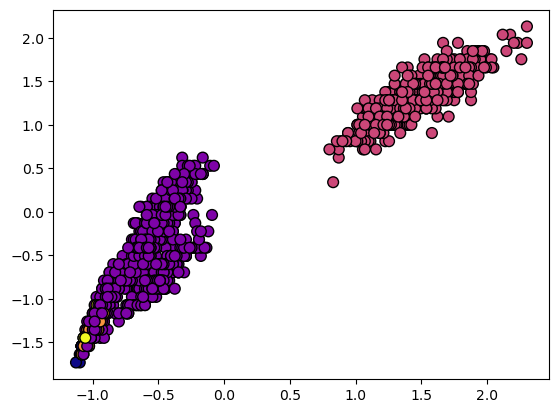

In [61]:
plt.scatter(skal_df[skal_df.columns[0]], skal_df[skal_df.columns[1]],
            c=clusters, cmap='plasma', s=60, edgecolors='black')


In [ ]:
pd.Series(clusters).value_counts()